## FD_abs[hhb2] ANN Fitting

In [1]:
import sys
from google.colab import drive
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/MCX_data'
sys.path.append(folder_path)

Mounted at /content/drive


In [2]:
import pandas as pd
import glob
import os
import numpy as np
import sys
import pickle
from tqdm import tqdm
! pip install pmcx
from concurrent.futures import ThreadPoolExecutor
#from FDNIRS_dprocesser import load_and_process_all as lapa
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.9 MB/s eta 0:00:00


### Read Simulation data

In [3]:
# -*- coding: utf-8 -*-
# Train an ANN to predict HHB2 from MCX simulation pickles.

import os, re, pickle, math, random
from pathlib import Path
from typing import Any, Iterable

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

Found 3000 matching pickles with GT.


Loading (threads):   0%|          | 0/3000 [00:00<?, ?file/s]

Feature matrix: (3000, 404) | Targets: (3000,)
Split sizes → train: 2700, val: 150, test: 150
Normalization → X: GLOBAL, y: GLOBAL
[0]	validation_0-rmse:0.98658


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:26:01] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [21:26:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:0.98294
[200]	validation_0-rmse:0.97953
[300]	validation_0-rmse:0.97645
[400]	validation_0-rmse:0.97421
[500]	validation_0-rmse:0.97189
[600]	validation_0-rmse:0.96995
[700]	validation_0-rmse:0.96779
[800]	validation_0-rmse:0.96654
[900]	validation_0-rmse:0.96576
[1000]	validation_0-rmse:0.96491
[1100]	validation_0-rmse:0.96393
[1200]	validation_0-rmse:0.96280
[1300]	validation_0-rmse:0.96255
[1400]	validation_0-rmse:0.96188
[1500]	validation_0-rmse:0.96129
[1600]	validation_0-rmse:0.96086
[1700]	validation_0-rmse:0.96046
[1800]	validation_0-rmse:0.96032
[1900]	validation_0-rmse:0.96004
[2000]	validation_0-rmse:0.95991
[2100]	validation_0-rmse:0.95969
[2200]	validation_0-rmse:0.95979
[2300]	validation_0-rmse:0.95970
[2400]	validation_0-rmse:0.95998
[2500]	validation_0-rmse:0.96013
[2600]	validation_0-rmse:0.96015
[2700]	validation_0-rmse:0.96030
[2800]	validation_0-rmse:0.96039
[2900]	validation_0-rmse:0.96062
[3000]	validation_0-rmse:0.96070
[3100]	validation_0

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1028: UserWarning: [22:00:45] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  self.get_booster().save_model(fname)



✓ Saved best XGBoost model to best_xgb_hhb2.json

=== TEST METRICS (best XGB, original units) ===
MAE : 4.655078
RMSE: 5.476333
R^2 : 0.145754


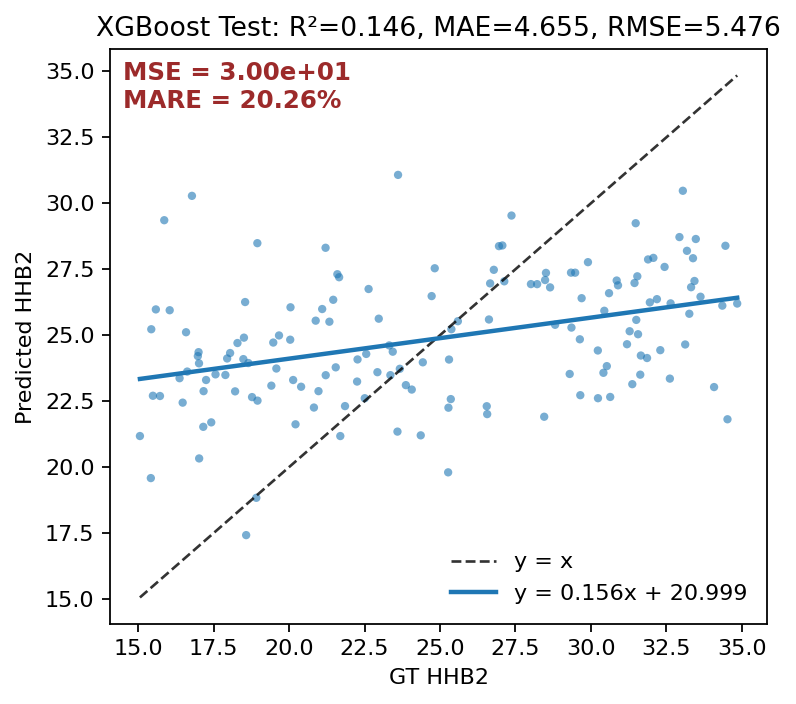


Sizes → Train: 2700, Val: 150, Test: 150


In [5]:
# -*- coding: utf-8 -*-
# Predict HHB2 from MCX simulation pickles (dict {10:[100], 30:[100]}) using XGBoost (GPU).
# Adds tqdm progress bar for data loading, with optional threaded I/O.

from pathlib import Path
import os, math, random, pickle
from typing import Any, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.utils import shuffle as sk_shuffle

import matplotlib.pyplot as plt

from xgboost import XGBRegressor

# Progress + threading
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor

# ---------------------
# Paths / Config
# ---------------------
RESULT_ROOT = Path('/content/drive/MyDrive/MCX_data/result_folder/cw_stage1')  # part1..part20
GT_CSV      = Path('/content/drive/MyDrive/MCX_data/cw_stage1_csv/satge1.csv') # columns: ID, HHB2

TARGET_COL  = 'HHB2'
ID_COL      = 'ID'

EACH_LEN    = 101                 # 10→[100], 30→[100]
INPUT_DIM   = 4 * EACH_LEN        # 200 features
TEST_SIZE   = 0.05
VAL_SIZE    = 0.05
SEED        = 1337

BEST_MODEL  = 'best_xgb_hhb2.json'

# Global normalization flags
GLOBAL_NORMALIZE_X = True
GLOBAL_NORMALIZE_Y = True

# Data-loading performance
USE_THREADS = True
NUM_WORKERS = min(32, (os.cpu_count() or 8) * 2)

# Optional: save splits to disk
SAVE_SPLITS = False
SAVE_DIR = Path('/content/xgb_hhb2_splits')

# XGBoost hyperparameters
XGB_PARAMS = dict(
    n_estimators=20000,
    learning_rate=0.0005,
    max_depth=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective='reg:squarederror',
    tree_method='gpu_hist',         # GPU training
    predictor='gpu_predictor',      # GPU inference
    random_state=SEED,
    verbosity=1
)

# ---------------------
# Repro
# ---------------------
random.seed(SEED)
np.random.seed(SEED)

# ---------------------
# Helpers
# ---------------------
def _as_float1d(x, want_len):
    a = np.asarray(x, dtype=np.float32).ravel()
    if a.size == want_len:
        return a
    # safety resample if not exact length
    xp = np.linspace(0.0, 1.0, max(1, a.size), dtype=np.float32)
    xnew = np.linspace(0.0, 1.0, want_len, dtype=np.float32)
    return np.interp(xnew, xp, a).astype(np.float32)

def load_pickle_feature(pkl_path: Path, each_len: int = EACH_LEN) -> np.ndarray:
    """
    Each pickle is a dict with keys 10 and 30, each length ~ each_len.
    Return a 200-D vector: [vals@10 (each_len), vals@30 (each_len)].
    """
    with open(pkl_path, 'rb') as f:
        obj = pickle.load(f)

    def get_key(d, k):
        if k in d: return d[k]
        sk = str(k)
        if sk in d: return d[sk]
        raise KeyError(f"Missing key {k} (/'{sk}') in {pkl_path}")

    v10  = _as_float1d(get_key(obj, 10), each_len)
    v20  = _as_float1d(get_key(obj, 20), each_len)
    v30  = _as_float1d(get_key(obj, 30), each_len)
    v40  = _as_float1d(get_key(obj, 40), each_len)

    feat = np.concatenate([v10, v20, v30, v40], axis=0).astype(np.float32)
    #if feat.size != 2 * each_len:
    #    raise ValueError(f"{pkl_path}: got {feat.size}, expected {2*each_len}")

    return feat

# ---------------------
# Read GT and build ID -> target mapping
# ---------------------
gt_df = pd.read_csv(GT_CSV)
cols_lc = {c.lower(): c for c in gt_df.columns}
if ID_COL.lower() not in cols_lc or TARGET_COL.lower() not in cols_lc:
    raise ValueError(f"CSV must contain '{ID_COL}' and '{TARGET_COL}'. Found: {list(gt_df.columns)}")

ID_COL_REAL     = cols_lc[ID_COL.lower()]
TARGET_COL_REAL = cols_lc[TARGET_COL.lower()]

id_to_target = dict(zip(gt_df[ID_COL_REAL].astype(int).tolist(),
                        gt_df[TARGET_COL_REAL].astype(float).tolist()))

# ---------------------
# Scan folders and gather (ID, pkl path)
# ---------------------
pairs: list[Tuple[int, Path]] = []
for sub in sorted(RESULT_ROOT.glob('part*')):
    if not sub.is_dir():
        continue
    for p in sorted(sub.glob('*.pkl')):
        try:
            pid = int(Path(p).stem)  # filename like "123.pkl"
        except Exception:
            continue
        if pid in id_to_target:
            pairs.append((pid, p))

if not pairs:
    raise RuntimeError("No matching (ID, pickle) pairs found. Check folders/filenames.")

print(f"Found {len(pairs)} matching pickles with GT.")

# ---------------------
# Build dataset X (N,200), y (N,) with progress bar
# ---------------------
N = len(pairs)
X = np.empty((N, INPUT_DIM), dtype=np.float32)
y = np.empty(N, dtype=np.float32)
kept_ids = np.empty(N, dtype=np.int64)

if USE_THREADS:
    def _worker(args):
        i, (pid, p) = args
        feat = load_pickle_feature(p, EACH_LEN)
        if feat.size != INPUT_DIM:
            raise ValueError(f"{p}: feature length {feat.size} != {INPUT_DIM}")
        return i, pid, feat

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as ex:
        for i, pid, feat in tqdm(ex.map(_worker, enumerate(pairs)),
                                 total=N, desc="Loading (threads)", unit="file"):
            X[i] = feat
            y[i] = float(id_to_target[pid])
            kept_ids[i] = int(pid)
else:
    for i, (pid, p) in tqdm(enumerate(pairs), total=N,
                            desc="Loading (sequential)", unit="file"):
        feat = load_pickle_feature(p, EACH_LEN)
        if feat.size != INPUT_DIM:
            raise ValueError(f"{p}: feature length {feat.size} != {INPUT_DIM}")
        X[i] = feat
        y[i] = float(id_to_target[pid])
        kept_ids[i] = int(pid)

# Optional shuffle (keeps pairs aligned)
X, y = sk_shuffle(X, y, random_state=SEED)

print(f"Feature matrix: {X.shape} | Targets: {y.shape}")

# ---------------------
# Split 80/10/10
# ---------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)
val_frac_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac_of_trainval, random_state=SEED
)

print(f"Split sizes → train: {len(y_train)}, val: {len(y_val)}, test: {len(y_test)}")

# (Optional) save splits
if SAVE_SPLITS:
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        SAVE_DIR / 'splits.npz',
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        X_test=X_test,   y_test=y_test,
        kept_ids=kept_ids
    )
    print(f"✓ Saved splits to {SAVE_DIR}")

# ---------------------
# Global z-score normalization (X and y)
# ---------------------
if GLOBAL_NORMALIZE_X:
    x_mean = X.mean(axis=0, keepdims=True)
    x_std  = X.std(axis=0, keepdims=True) + 1e-8
else:
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std  = X_train.std(axis=0, keepdims=True) + 1e-8

def zscore_X(a): return (a - x_mean) / x_std

X_train_n = zscore_X(X_train).astype(np.float32)
X_val_n   = zscore_X(X_val).astype(np.float32)
X_test_n  = zscore_X(X_test).astype(np.float32)

if GLOBAL_NORMALIZE_Y:
    y_mean = float(y.mean())
    y_std  = float(y.std() + 1e-8)
else:
    y_mean = float(y_train.mean())
    y_std  = float(y_train.std() + 1e-8)

def zscore_y(a): return (a - y_mean) / y_std
def inv_zscore_y(a): return a * y_std + y_mean

y_train_n = zscore_y(y_train).astype(np.float32)
y_val_n   = zscore_y(y_val).astype(np.float32)
# y_test left in original units; we only normalize to be consistent with model training if needed

print(f"Normalization → X: {'GLOBAL' if GLOBAL_NORMALIZE_X else 'TRAIN-only'}, "
      f"y: {'GLOBAL' if GLOBAL_NORMALIZE_Y else 'TRAIN-only'}")

# ---------------------
# Train XGBoost (GPU)
# ---------------------
model = XGBRegressor(**XGB_PARAMS)

# Correct eval_set API: list of (X, y) tuples
model.fit(
    X_train_n, y_train_n,
    eval_set=[(X_val_n, y_val_n)],
    verbose=100,
)

# Save best model
model.save_model(BEST_MODEL)
print(f"\n✓ Saved best XGBoost model to {BEST_MODEL}")

# ---------------------
# Load best model & Test (de-normalize predictions)
# ---------------------
best = XGBRegressor()
best.load_model(BEST_MODEL)

pred_test_n = best.predict(X_test_n).astype(np.float64)
pred_test   = inv_zscore_y(pred_test_n)   # back to original HHB2 units

# Metrics in ORIGINAL units
mae  = mean_absolute_error(y_test, pred_test)
rmse = math.sqrt(mean_squared_error(y_test, pred_test))
r2   = r2_score(y_test, pred_test)

print("\n=== TEST METRICS (best XGB, original units) ===")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R^2 : {r2:.6f}")

# ---------------------
# Plot GT vs Pred with identity & best-fit line + MSE/MARE
# ---------------------
mse  = mean_squared_error(y_test, pred_test)
mare = np.mean(np.abs((pred_test - y_test) / np.clip(np.abs(y_test), 1e-8, None))) * 100.0

plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test, pred_test, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test), np.min(pred_test)))
hi = float(max(np.max(y_test), np.max(pred_test)))
if not (np.isfinite(lo) and np.isfinite(hi)) or lo == hi:
    lo, hi = -1.0, 1.0

# Identity line
plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

# Best-fit line
if np.std(y_test) > 0:
    a, b = np.polyfit(y_test, pred_test, 1)
    xx = np.linspace(lo, hi, 200)
    plt.plot(xx, a * xx + b, lw=2, label=f'y = {a:.3f}x + {b:.3f}')

plt.xlabel("GT HHB2")
plt.ylabel("Predicted HHB2")
plt.title(f"XGBoost Test: R²={r2:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")
plt.text(0.02, 0.98, f"MSE = {mse:.2e}\nMARE = {mare:.2f}%",
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.show()

# ---------------------
# Sizes
# ---------------------
print(f"\nSizes → Train: {len(y_train)}, Val: {len(y_val)}, Test: {len(y_test)}")

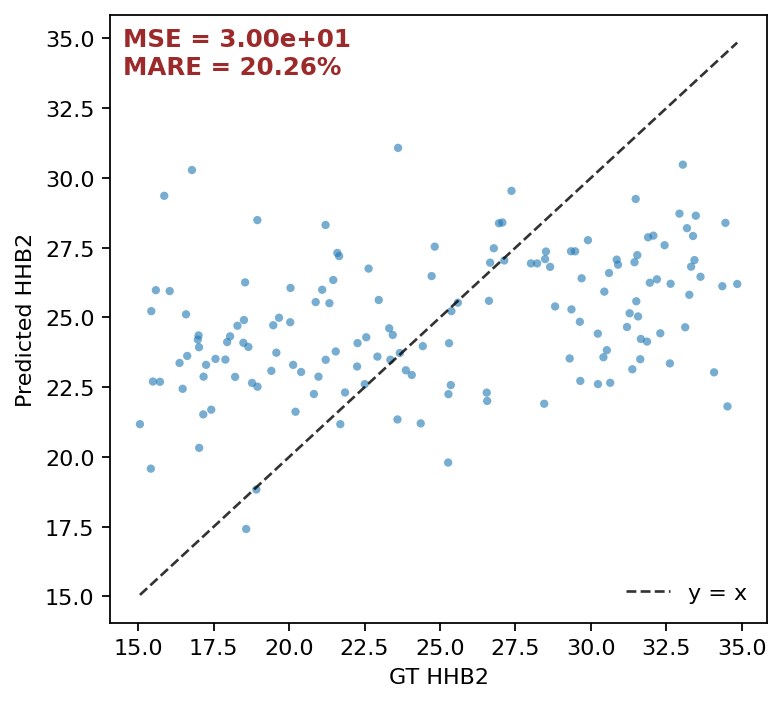

In [6]:
# ---- Plot GT vs Pred (original units) ----
mse  = mean_squared_error(y_test, pred_test)
mare = np.mean(np.abs((pred_test - y_test) / np.clip(np.abs(y_test), 1e-8, None))) * 100.0

# ---- Plot GT vs Pred (original units) ----
plt.figure(figsize=(5, 4.5), dpi=160)
plt.scatter(y_test, pred_test, s=14, alpha=0.6, edgecolors='none')

lo = float(min(np.min(y_test), np.min(pred_test)))
hi = float(max(np.max(y_test), np.max(pred_test)))
if not (np.isfinite(lo) and np.isfinite(hi)) or lo == hi:
    lo, hi = -1.0, 1.0

# Keep ONLY the identity line (dashed); remove best-fit line
plt.plot([lo, hi], [lo, hi], 'k--', lw=1.2, alpha=0.8, label='y = x')

plt.xlabel("GT HHB2")
plt.ylabel("Predicted HHB2")
plt.text(0.02, 0.98, f"MSE = {mse:.2e}\nMARE = {mare:.2f}%",
         transform=plt.gca().transAxes, va='top', ha='left',
         color='#9c2a2a', fontsize=11, fontweight='bold')
# optional: show legend for the identity line; remove if you don't want it
plt.legend(loc='lower right', frameon=False)

plt.tight_layout()
plt.show()


In [7]:
y_test

array([23.608654 , 27.065685 , 33.320568 , 20.971935 , 21.596935 ,
       31.860607 , 15.0539665, 34.355724 , 29.29713  , 19.472912 ,
       18.945568 , 17.24635  , 31.372326 , 26.62135  , 26.562756 ,
       33.125256 , 34.458263 , 22.553967 , 17.417248 , 19.57545  ,
       18.4817   , 32.44166  , 31.284435 , 24.360607 , 33.384045 ,
       29.634045 , 19.663342 , 18.501232 , 31.504162 , 20.0442   ,
       32.934826 , 22.632092 , 34.84889  , 28.01295  , 16.582287 ,
       21.655529 , 16.367443 , 30.898693 , 30.415295 , 31.48463  ,
       31.196545 , 15.718029 , 15.58131  , 18.911388 , 26.782482 ,
       29.692638 , 34.082287 , 16.972912 , 32.641857 , 16.7776   ,
       20.210217 , 21.460217 , 17.163342 , 16.040295 , 17.153576 ,
       15.859631 , 17.944592 , 20.879162 , 29.477795 , 25.298107 ,
       33.633068 , 23.354748 , 23.432873 , 15.415295 , 23.315685 ,
       31.538342 , 31.95338  , 28.647717 , 18.574474 , 31.635998 ,
       23.589123 , 28.452404 , 22.505138 , 33.18385  , 21.8508

In [8]:
pred_test

array([31.07738598, 28.40120477, 26.81782136, 22.8767433 , 27.31089338,
       24.1332509 , 21.17514319, 26.11895412, 23.52866046, 24.71981985,
       28.48853218, 23.29968282, 23.14145778, 25.59449982, 22.006599  ,
       24.64688352, 28.38931148, 24.28824513, 21.69335366, 23.73514313,
       24.09194877, 27.58799514, 25.14872862, 21.20128387, 27.91780083,
       24.84324892, 24.98903411, 24.9059998 , 25.57878147, 26.05701973,
       28.7193307 , 26.75040376, 26.19905606, 26.93627843, 25.11090385,
       27.19680382, 23.3676006 , 26.88976838, 23.57252048, 29.24513819,
       24.65633005, 22.69270982, 25.97668577, 18.83234802, 27.47785808,
       26.40197775, 23.03227977, 24.20668664, 26.20561394, 30.28255569,
       21.61968245, 26.34149457, 22.87663146, 25.9452668 , 21.52443938,
       29.35889533, 24.11601229, 25.54991789, 27.36906152, 24.07555522,
       26.45719829, 23.48364507, 24.3733985 , 19.58017291, 24.61059609,
       27.23188272, 26.24320221, 26.81196384, 17.41781781, 23.50